In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.append("../src")


from geodesiq import *

# Ising spin chain (with QuSpin)

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Hamiltonian Eigenvalues'}, xlabel='lam', ylabel='Energy'>)

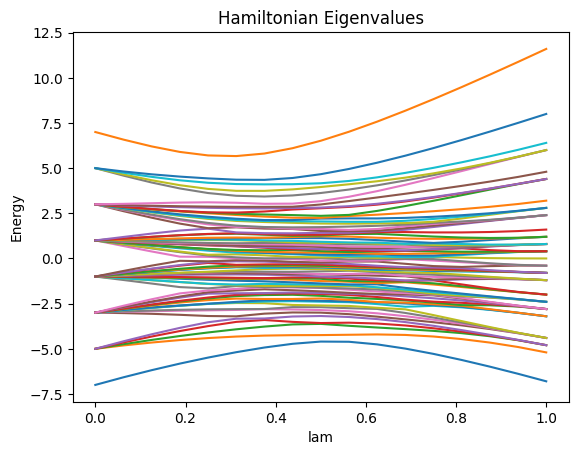

In [2]:
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d


def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising Hamiltonian with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i+1] for i in range(L-1)]
    z_list  = [[lam * hz, i] for i in range(L)]
    x_list  = [[(1-lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)
    
    return H.toarray()


ising = Hamiltonian(ising_model)

# ----- Set system and control parameters -----
alpha, beta = 2, 2

L, hx, hz = 7, 1, .8
lam0, lamf = 0, 1


ising.set_parameters(L=L, hx=hx, hz=hz)
ising.set_control(control_name='lam', pulse_initial=lam0, pulse_final=lamf,
                        initial_state=0, alpha=alpha, beta=beta, num_steps=2**4+1)

ising.plot_eigenvalues(legend=False)

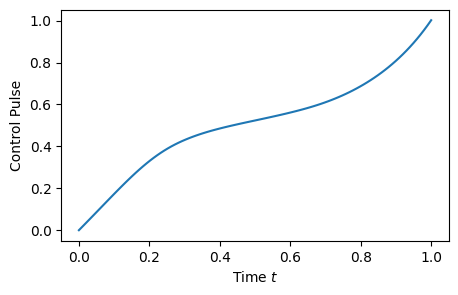

(<Figure size 500x300 with 1 Axes>,
 <Axes: xlabel='Time $t$', ylabel='Control Pulse'>)

In [3]:
ising.solve_problem(pulse_accuracy=int(100))
ising.synthesize_pulse(duration=1, method='plot')

# Time dependent simulations

In [4]:
# joblib is an additional Python package for parallel computing
from joblib import Parallel, delayed

# Progress bar
from tqdm import tqdm

In [5]:
def _worker_compute_fidelity(duration, hamiltonian):
    dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
    return dynamics.state_fidelity()

def fidelity_vs_time(durations, hamiltonian, L, n_jobs=-1):
    hamiltonian.set_parameters(L=L)
    hamiltonian.solve_problem(pulse_accuracy=int(100))

    # Run the loop in parallel
    fidelities = Parallel(n_jobs=n_jobs)(
        delayed(_worker_compute_fidelity)(duration, hamiltonian) 
        for duration in tqdm(durations, desc="Computing fidelities")
    )

    return np.array(fidelities)

In [6]:
durations = np.linspace(0.1, 1000, 20)
fidelities_L2 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=2)
fidelities_L4 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=4)

Computing fidelities: 100%|██████████| 20/20 [00:00<00:00, 16153.68it/s]


In [7]:
fidelities_L6 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=6)

Computing fidelities: 100%|██████████| 20/20 [00:00<00:00, 15196.75it/s]


In [8]:
fidelities_L8 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=8)

Computing fidelities: 100%|██████████| 20/20 [00:00<00:00, 17597.25it/s]


In [16]:
fidelities_L10 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=10)

Computing fidelities: 100%|██████████| 20/20 [00:00<00:00, 1771.32it/s]


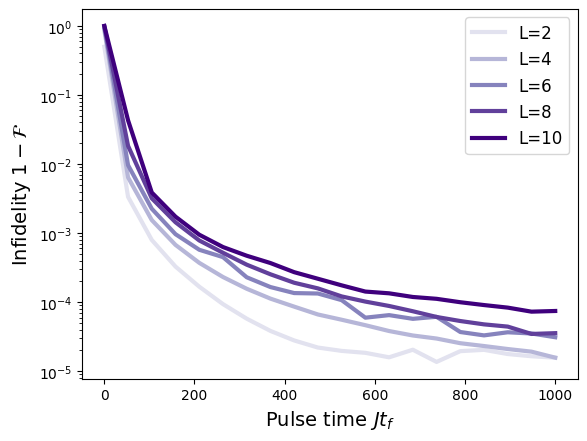

In [21]:
import matplotlib.cm as cm

L_vals = np.array([2,4,6,8,10])
norm = plt.Normalize(vmin=L_vals.min()-2, vmax=L_vals.max())
colors_rgba = cm.Purples(norm(L_vals))

data = {
    'L=2': fidelities_L2,
    'L=4': fidelities_L4,
    'L=6': fidelities_L6,
    'L=8': fidelities_L8,
    'L=10': fidelities_L10
}

for (label, fidelities) in data.items():
    plt.plot(durations, 1-fidelities, label=label, lw=3, color=colors_rgba[int(label.split('=')[1])//2 - 1])

plt.yscale('log')
plt.ylabel('Infidelity $1-\mathcal{F}$', fontsize=14)
plt.xlabel('Pulse time $J t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()